In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
from processing import filter_region, sort_max_arr, remove_rate
from visualizations import lineplots_4x4, smooth_func
from datetime import datetime

# load prediction arrays, create array objects

In [2]:
folder_path = 'predictions/8-27-2025/'

In [3]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [4]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [5]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [6]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [7]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [8]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [9]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [10]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


remove anything above 200 spikes/sec

In [11]:
mean_v1_removed = remove_rate(mean_v1, 200)

In [12]:
print('mean shape:', mean_v1_removed.shape)

mean shape: (110, 5312)


In [13]:
np.unique(np.isnan(mean_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [14]:
var_v1_removed = np.where(np.isnan(mean_v1_removed), mean_v1_removed, var_v1)

In [15]:
print('var shape:', var_v1_removed.shape)

var shape: (110, 5312)


In [16]:
np.unique(np.isnan(var_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [17]:
test_neuron = 250

In [18]:
mean_v1_removed[..., test_neuron]

array([ 1.2463064 ,  1.24020794,  1.25462661,  1.24655529,  1.2425826 ,
        1.25153601,  1.2398717 ,  1.24163726,  1.2480869 ,  1.24156901,
        6.37779003,  2.54841062,  0.90853661,  4.65332162,  2.21029007,
        1.35951157,  6.54871568,  1.36838745,  0.90229548,  3.83509161,
        3.83487322,  1.35078649,  3.32662263,  8.25588995,  6.0524421 ,
        3.22314709,  1.72692854,  3.21568874, 21.89021402,  1.2630467 ,
        1.63322649,  5.63047903,  5.40039839,  3.32853719, 15.53215022,
        3.39507595,  0.62955402,  6.13283806, 10.41562607,  2.61652664,
        1.27100447,  9.6138177 ,  4.62776532, 13.49668428,  2.41314971,
        3.00902056,  5.39590202,  3.55865272,  6.25919223,  1.06665893,
        0.72649008,  3.1069436 ,  6.3636409 ,  2.24445013,  4.06503166,
        3.88841465,  3.19797114,  9.17677807, 17.50732809,  1.05598657,
        1.20878679,  1.27737361,  2.52204806,  1.12632903,  1.30531135,
        1.08834569, 18.82170198,  1.74326626,  4.27722898,  2.21

In [19]:
var_v1_removed[..., test_neuron]

array([5.89519778e-03, 6.25225449e-03, 5.64696894e-03, 7.58986399e-03,
       8.44021462e-03, 8.26533545e-03, 6.82200535e-03, 6.09422311e-03,
       5.67081193e-03, 1.00324913e-02, 2.23116135e-01, 4.72871449e-02,
       1.70939150e-03, 1.10786283e-01, 3.36602995e-02, 8.61004195e-03,
       2.18050575e-01, 1.12997696e-02, 4.55823124e-03, 5.70135352e-02,
       7.09870565e-02, 5.83171457e-03, 9.25808855e-02, 7.42191340e-01,
       2.33131671e-01, 5.28287135e-02, 9.60795727e-03, 9.09330979e-02,
       4.70275761e+00, 8.48655071e-03, 1.77596737e-02, 2.08138842e-01,
       1.34898624e-01, 4.03271419e-02, 2.13739022e+00, 8.47248433e-02,
       1.00310265e-03, 3.02719337e-01, 7.41405904e-01, 4.72942837e-02,
       5.21759589e-03, 5.27805192e-01, 1.62557925e-01, 1.02839045e+00,
       2.79139484e-02, 7.82202498e-02, 1.49322907e-01, 1.14970853e-01,
       3.52514036e-01, 5.78027666e-03, 6.37661664e-04, 5.82232829e-02,
       2.63737339e-01, 1.67510495e-02, 1.01280631e-01, 1.08535081e-01,
      

get indices to sort

In [20]:
print(f'unique counts for mean_arr:', np.unique(np.isnan(mean_v1_removed), return_counts = True))
print(f'unique counts for var_arr:', np.unique(np.isnan(var_v1_removed), return_counts = True))
print('ensure that we have the same counts for both arrays')

unique counts for mean_arr: (array([False,  True]), array([582882,   1438]))
unique counts for var_arr: (array([False,  True]), array([582882,   1438]))
ensure that we have the same counts for both arrays


In [21]:
max_arr = np.nanmax(mean_v1_removed, axis = 0)
max_arr.shape

(5312,)

In [22]:
for max_num in max_arr: print(max_num)

18.20643789894879
6.871708573102951
18.54305610060692
65.1902556309104
19.2026533728838
15.230209202766419
39.336862547397615
60.866338631510736
24.836072195768356
17.975822390019893
30.195233067274092
63.22873750656843
59.27374358162284
83.30904997348786
59.56254869401455
24.6268798533082
40.3407887750864
32.41425412416458
30.576551679372788
10.919594417065381
46.26562501847744
97.08155757695437
24.8718533847481
47.67963366419077
30.58293590322137
25.131206027269364
20.26397334419191
11.6168127271533
26.99751196742058
11.24400021135807
28.633289091289043
13.28748903721571
55.28955410152674
27.113712515234948
39.34162843197584
20.99816920876503
14.628332357406617
32.82596981823444
42.36594277203083
25.944959621429444
74.61379934772849
20.55546413719654
31.60792947024107
56.76102456122637
23.22874755144119
22.558681053519248
95.17302981883287
20.167560538724064
25.838633379340173
23.257161124646665
82.00981669396162
48.55731274276972
36.56576255649328
35.096241635978224
57.4356507651507

In [23]:
sort_indices = np.argsort(max_arr)[::-1]

In [24]:
len(sort_indices)

5312

In [25]:
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

In [26]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.nanmax(mean_v1_sorted[..., neuron]))

99.99202925011515
99.89384714007377
99.89251179873943
99.81552377641201
99.77965465247631
99.76727227032184
99.74895481944084
99.71723401188851
99.71366840451955
99.68118857830763
99.68087560251355
99.67227961957455
99.66545183509588
99.5967887365818
99.58855407208205
99.5604840490222
99.50625397145748
99.4747419604659
99.44617527276277
99.38542845919729
99.30909102410078
99.17377379715442
99.16192821532488
99.09417723238468
99.09102210789919
99.07794129997492
99.02941989600659
99.001331115067
98.92751202225685
98.9137511150539
98.91339938521385
98.89178261429072
98.82756403326988
98.82212929129601
98.8213679498434
98.80776161402464
98.77204619109631
98.72408289313316
98.65785360574722
98.63911096990108
98.61377671048045
98.59560651630163
98.56659649372101
98.49599428266286
98.47722938060761
98.47481096744538
98.38140952780843
98.37774061977863
98.30632414460182
98.23264676243066
98.21956773519516
98.2031313124299
98.07160914346576
97.94320685625077
97.88476485520601
97.83553854554891


In [27]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.max(mean_v1_sorted[..., neuron]))

nan
nan
nan
nan
nan
nan
nan
nan
99.71366840451955
nan
nan
nan
99.66545183509588
nan
nan
99.5604840490222
99.50625397145748
nan
nan
nan
nan
99.17377379715442
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
98.8213679498434
nan
nan
98.72408289313316
nan
98.63911096990108
nan
98.59560651630163
nan
nan
nan
98.47481096744538
nan
nan
nan
nan
nan
nan
98.07160914346576
nan
nan
nan
nan
nan
nan
97.61833022251726
nan
97.51652378797532
nan
nan
nan
nan
97.27784715235234
nan
nan
97.16618258237838
nan
97.06345617800952
nan
nan
nan
nan
96.95640642911195
nan
96.91965165257454
nan
96.83096684366464
96.75162558794021
nan
96.73176958411932
96.62736427545548
nan
96.53850479632617
96.53574280679226
nan
96.47643038868904
96.4580698889494
nan
nan
96.35980370923876
nan
nan
nan
nan
96.21908628225327
nan
nan
96.06287498354912
nan
96.00447511300445
nan
nan
nan
nan
95.91987080276013
95.91849799096585
nan
nan
95.66345950901508
nan
nan
95.60825437903404
95.58306640625
nan
95.5535879933834
nan
nan
95.41781040668488
n

#### *note that this code works and has been checked properly up to here*

In [28]:
mean_v1_sorted[...,110]

array([41.75073332, 41.44852212, 41.79499455, 41.0159401 , 41.07259802,
       41.17877123, 41.12015039, 40.87292784, 41.19426196, 41.07837856,
       13.17820978, 30.61572335,  7.97491274, 56.40862193, 47.94809609,
       48.59972301, 95.83737383, 43.28874619, 27.10424738, 33.81041813,
        6.13439804, 29.14951965, 59.88005825, 41.14431924,         nan,
               nan, 22.47233576, 66.51245729, 56.9680189 , 40.96571084,
       23.54962022,  9.58975631, 36.82860436, 15.95831185,         nan,
       41.89279869,  6.7170004 , 77.85117014, 27.24574081, 52.59270066,
       20.61831589, 50.39686866, 21.25352828, 37.3090949 , 39.62764803,
       30.58956772,  2.59527433,  6.04737844, 47.56202706, 46.09045077,
        8.43238849, 60.31219155, 61.83896149, 12.27663216, 60.03265781,
       66.24740595, 26.87401325, 18.55314533, 41.24766667,  7.14926002,
       17.5027323 , 42.89608404, 58.33047105, 22.82481655, 30.34447967,
        8.93249436, 41.72396541, 65.82042946, 10.05440193, 25.87

In [29]:
var_v1_sorted[..., 110]

array([1.56700828e+01, 1.07712454e+01, 1.53993037e+01, 1.64195777e+01,
       1.20276124e+01, 1.06120177e+01, 1.16330757e+01, 1.20120604e+01,
       1.06881341e+01, 1.21586891e+01, 1.05879374e+00, 6.15832519e+00,
       2.64573538e-01, 2.84119175e+01, 1.70824426e+01, 1.62684703e+01,
       7.63610707e+01, 1.54759572e+01, 5.75559455e+00, 7.60190305e+00,
       9.42777698e-02, 6.32559153e+00, 2.62238167e+01, 1.39269528e+01,
                  nan,            nan, 2.84294671e+00, 2.73025968e+01,
       1.84861090e+01, 1.31813914e+01, 4.44812246e+00, 6.20121893e-01,
       8.75260382e+00, 1.51846468e+00,            nan, 2.00119191e+01,
       1.55099507e-01, 7.16551602e+01, 5.46199132e+00, 1.74466584e+01,
       3.26541012e+00, 2.12284989e+01, 2.83929707e+00, 1.40517200e+01,
       1.10039555e+01, 5.06886468e+00, 8.21987950e-03, 1.10607824e-01,
       2.02310256e+01, 2.11781575e+01, 3.19529871e-01, 3.55600431e+01,
       2.64384786e+01, 8.80041164e-01, 2.10786629e+01, 4.31434432e+01,
      

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:780: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)


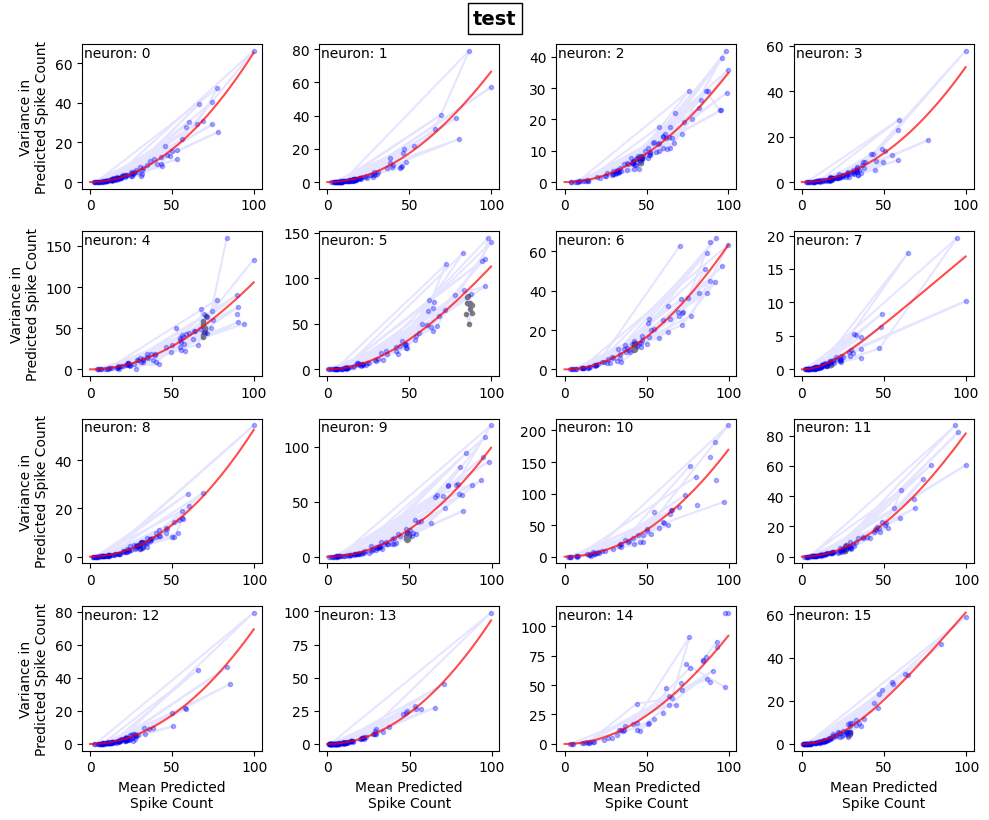

In [30]:
lineplots_4x4('test', [i for i in range(16)], mean_v1_sorted, var_v1_sorted)

# regression

In [31]:
test_neuron = 4508

test_means = mean_v1_sorted[..., test_neuron]
test_vars = var_v1_sorted[..., test_neuron]

In [32]:
from scipy.optimize import curve_fit
mask = ~np.isnan(test_means)
means_nonan = test_means[mask]
vars_nonan = test_vars[mask]

params, covariance = curve_fit(smooth_func, means_nonan, vars_nonan)

In [33]:
means_nonan

array([ 2.07157331,  2.06305897,  2.06925401,  2.07147122,  2.06530066,
        2.05380107,  2.06529609,  2.07663695,  2.07168157,  2.09127432,
        4.38843495,  1.29767069,  4.44433334,  3.42584599,  4.23352902,
        2.09183947,  0.83139352,  1.90767421,  1.60129324,  2.20123644,
        7.53177772,  4.78347987,  0.89892506,  0.76138383,  1.43846672,
        1.76056668,  8.33550391,  2.93630932,  1.12392856,  1.90869515,
        2.24922266,  5.7753997 ,  6.43420108,  4.46401592,  6.49514516,
        3.12384507,  2.3141734 ,  4.2183739 ,  6.99247767,  1.52144456,
        2.27661347,  0.88211372,  1.53712097,  3.38243198,  2.06321439,
        3.98172609, 13.99212207,  5.41750274,  1.04890757,  2.06841416,
        2.60778532,  3.68498946,  0.88763611,  2.52059799,  4.9745952 ,
        4.79130356,  3.75322263, 11.42748977,  0.77129392,  2.64548945,
        2.07967455,  2.83091768,  1.69514202,  2.71376208,  1.34258847,
        7.78475371,  0.64300645,  2.28543527,  1.73257452,  2.98

In [34]:
vars_nonan

array([9.59556972e-03, 7.79782187e-03, 1.12901959e-02, 9.03933382e-03,
       7.79733828e-03, 9.04397971e-03, 8.02150975e-03, 9.32840819e-03,
       1.19312824e-02, 9.20807639e-03, 6.52054447e-02, 4.93431269e-03,
       6.79053357e-02, 6.09648367e-02, 5.71325730e-02, 1.06216985e-02,
       1.57286934e-03, 8.11818797e-03, 6.82222741e-03, 1.47623599e-02,
       1.31812481e-01, 1.03374160e-01, 1.27141280e-03, 8.01899383e-04,
       9.08364221e-03, 1.00120077e-02, 2.43610129e-01, 2.80482312e-02,
       1.54494946e-03, 7.71006983e-03, 1.31840774e-02, 1.68116558e-01,
       1.94263349e-01, 4.31356613e-02, 1.18100020e-01, 2.85387174e-02,
       7.11977193e-03, 6.52410362e-02, 2.05099076e-01, 5.07045778e-03,
       1.52735479e-02, 1.57472681e-03, 5.73416391e-03, 3.44026170e-02,
       1.02916315e-02, 3.41715782e-02, 7.57954598e-01, 9.43395506e-02,
       1.64084352e-03, 9.99762210e-03, 6.64381410e-03, 4.78960557e-02,
       1.05231916e-03, 1.41910280e-02, 1.13956093e-01, 5.71110099e-02,
      

In [35]:
params

array([9.59456948e+00, 3.46212707e-03])

In [36]:
y_pred = smooth_func(np.linspace(0, np.max(means_nonan)), params[0], params[1])

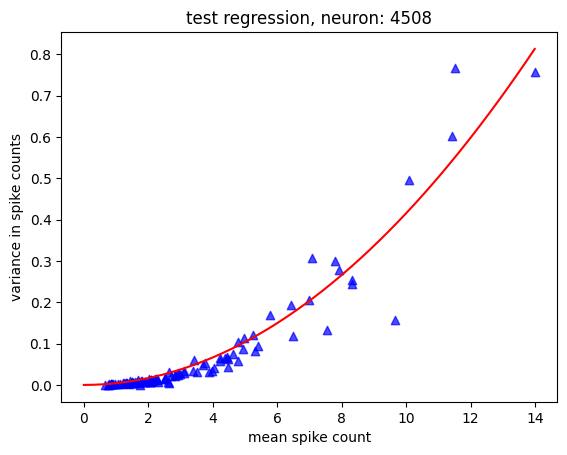

In [37]:
plt.scatter(test_means, test_vars, marker = '^', color = 'b', alpha = 0.7)
plt.plot(np.linspace(0, np.max(means_nonan)), y_pred, color = 'r')
plt.title(f'test regression, neuron: {test_neuron}')
plt.xlabel('mean spike count')
plt.ylabel('variance in spike counts')
plt.show()

# function with regression

In [88]:
def lineplots_4x4(main_title, neurons, mean_masked, var_masked, savefig = False):
    """
    ADD DOCS
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')
        ax.plot(mean_masked[..., neuron], var_masked[..., neuron], color = 'b', alpha = 0.1)

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan)
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan)), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan)), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

*smooth function*
$$
f(x) = \frac{m}{b} \left[ \ln(1 + e^{b x}) - \ln(2) - \frac{b x}{2} \right]
$$

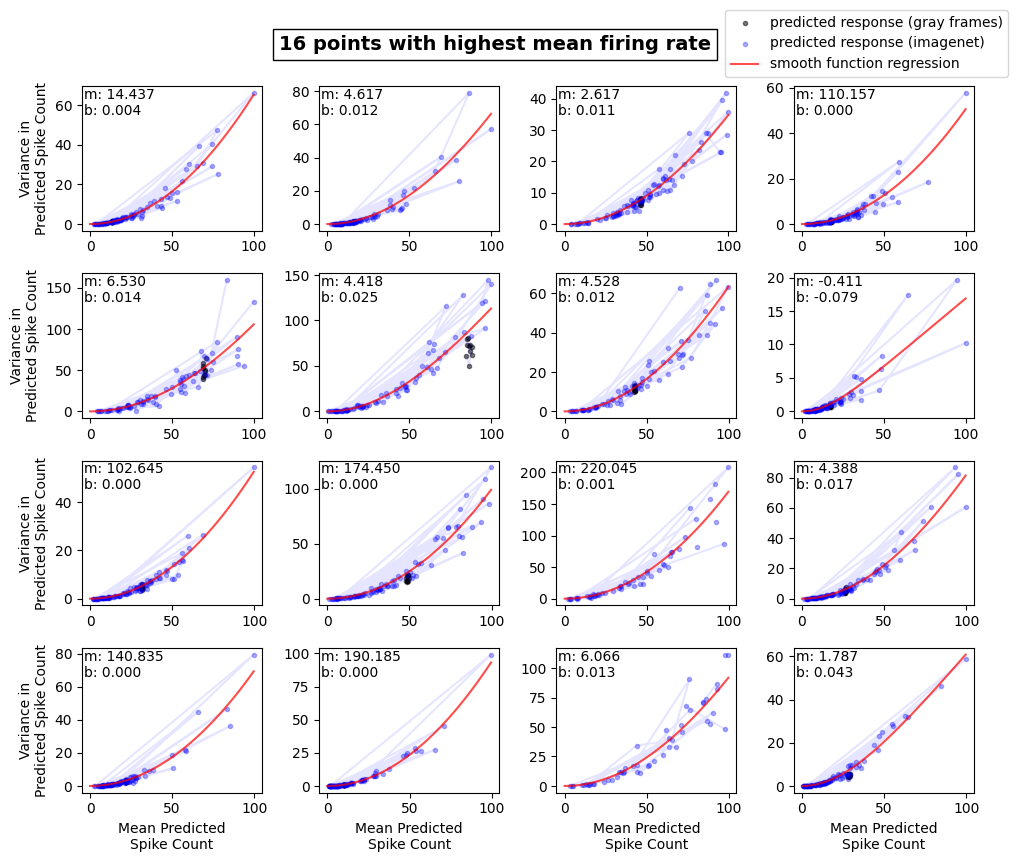

In [89]:
lineplots_4x4('16 points with highest mean firing rate', [i for i in range(16)], mean_v1_sorted, var_v1_sorted, False)